# Best Predictive Model for Proteomics using a Transformer Model

## Task Type and Model Decision
I selected a Transformer model because the multi-head attention can learn different types of relationships between omics data features and capturing various correlations that might exist. The self-attention mechanism allows the model to identify important feature interactions, which I think are important in multi-omics data integration. While VAEs would also be suitable, particularly for handling noise and missing values, the potential complex interactions between omics data features made Transformers my preferred choice.

## Data
The aim is to use multiple input omics datasets to predict proteomics data. Input omics data was selected by iteratively testing combinations to determine which best predicted proteomics. This indicated that transcriptomics data only as the optimal input combination for proteomics prediction (see EMBL_transformer_explore.ipynb).

## Plan
The approach follows a systematic comparison between a baseline MLP model and the Transformer architecture:

#### In multiomics_data_analysis.ipynb
1. [Inspect data](#inspect-data);

#### In multiomics_transformer_train.ipynb
2. [Create a simple MLP model](#baseline-mlp) as a baseline;
3. [Develop Transformer models](#transformer-models) with different fusion strategies and activation functions;
4. [Perform hyperparameter tuning](#hyperparameter-tuning);
5. [Conduct progressive input omics selection](#omics-selection);
6. [Create comprehensive loop](#evaluation-loop) to iterate through steps 3-5, obtaining metrics to determine the best Transformer model for comparison with the baseline MLP;

#### In multiomics_transformer_performance_analysis.ipynb
7. [Select best-performing model](#best-performing);
8. [Analyse best-predicted proteomic features](#feature-analysis);



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, Dataset

In [2]:
# for using VSCode
import sys

# Add the parent directory of transformer_multiomics to sys.path
sys.path.append(str(Path.cwd().parent))

In [3]:
from transformer_multiomics.config import DATA_PATH, MODEL_PATH, RESULT_PATH
from transformer_multiomics.data.data_loader import ensure_directories_exist, load_datasets
from transformer_multiomics.models.transformer import MultiOmicsTransformerFusion

In [4]:
# CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Select Best Performing Model <a id="best-performing"></a>

In [6]:
class MultiOmicsDataset(Dataset):
    def __init__(self, X_dict, y=None):
        self.X_dict = {k: torch.FloatTensor(v) for k, v in X_dict.items()}
        self.y = torch.FloatTensor(y) if y is not None else None

    def __len__(self):
        # Assuming all X datasets have the same length
        return len(next(iter(self.X_dict.values())))

    def __getitem__(self, idx):
        if self.y is not None:
            return {k: v[idx] for k, v in self.X_dict.items()}, self.y[idx]
        else:
            return {k: v[idx] for k, v in self.X_dict.items()}

In [7]:
def prepare_data_loaders(omics_set, datasets, test_size=0.2, batch_size=64, random_state=42):
    """
    Prepare data loaders for training, validation, and testing

    Parameters:
    -----------
    omics_set : list
        List of omics types to use
    datasets : dict
        Dictionary of DataFrames containing omics data
    test_size : float
        Proportion of data to use for testing
    batch_size : int
        Batch size for DataLoaders
    random_state : int
        Random seed for reproducibility

    Returns:
    --------
    train_loader : DataLoader
        DataLoader for training data
    val_loader : DataLoader
        DataLoader for validation data
    test_loader : DataLoader
        DataLoader for test data
    input_dims : dict
        Dictionary mapping each omics type to its dimensionality
    output_dim : int
        Dimensionality of the output (proteomics features)
    """
    from sklearn.model_selection import train_test_split

    # Get reference IDs from proteomics data
    reference_df = datasets["proteomics"]
    patient_id_col = reference_df.columns[0]
    reference_ids = list(reference_df[patient_id_col])

    # Extract omics data
    X_dict = {}
    for omics_type in omics_set:
        omics_df = datasets[omics_type]
        # Filter to reference IDs and exclude patient ID column
        omics_filtered = omics_df[omics_df[patient_id_col].isin(reference_ids)]
        X_dict[omics_type] = omics_filtered.iloc[:, 1:].values

    # Extract proteomics data (target)
    y = reference_df.iloc[:, 1:].values

    # Create input dimensions dictionary
    input_dims = {omics_type: X.shape[1] for omics_type, X in X_dict.items()}
    output_dim = y.shape[1]

    # Split data into train+val and test
    indices = np.arange(len(y))
    train_val_indices, test_indices = train_test_split(indices, test_size=test_size, random_state=random_state)

    # Split train+val into train and validation
    train_indices, val_indices = train_test_split(train_val_indices, test_size=test_size, random_state=random_state)

    # Create train, validation, and test dictionaries
    train_X = {k: v[train_indices] for k, v in X_dict.items()}
    val_X = {k: v[val_indices] for k, v in X_dict.items()}
    test_X = {k: v[test_indices] for k, v in X_dict.items()}

    train_y = y[train_indices]
    val_y = y[val_indices]
    test_y = y[test_indices]

    # Create datasets and data loaders
    train_dataset = MultiOmicsDataset(train_X, train_y)
    val_dataset = MultiOmicsDataset(val_X, val_y)
    test_dataset = MultiOmicsDataset(test_X, test_y)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, input_dims, output_dim

In [8]:
def adjust_checkpoint(checkpoint_path, model):
    """
    Adjust the checkpoint to match the model's architecture by resizing mismatched layers,
    adding missing keys, and removing unexpected keys.

    Parameters:
    -----------
    checkpoint_path : Path
        Path to the saved checkpoint file.
    model : nn.Module
        The model instance to match the checkpoint.

    Returns:
    --------
    adjusted_checkpoint_path : Path
        Path to the adjusted checkpoint file.
    """
    # Load the checkpoint
    state_dict = torch.load(checkpoint_path, map_location="cpu")

    # Get the model's state_dict
    model_state_dict = model.state_dict()

    # Adjust mismatched layers
    for key in list(state_dict.keys()):
        if key in model_state_dict:
            if state_dict[key].shape != model_state_dict[key].shape:
                print(f"Reshaping {key}: {state_dict[key].shape} -> {model_state_dict[key].shape}")
                # Create a new tensor with the correct shape and copy the data
                resized_tensor = torch.zeros_like(model_state_dict[key])
                min_shape = tuple(min(s1, s2) for s1, s2 in zip(state_dict[key].shape, resized_tensor.shape))
                resized_tensor[tuple(slice(0, s) for s in min_shape)] = state_dict[key][
                    tuple(slice(0, s) for s in min_shape)
                ]
                state_dict[key] = resized_tensor
        else:
            # Remove unexpected keys
            print(f"Removing unexpected key: {key}")
            del state_dict[key]

    # Add missing keys
    for key in model_state_dict:
        if key not in state_dict:
            print(f"Adding missing key: {key}")
            state_dict[key] = model_state_dict[key]

    # Save the adjusted checkpoint
    adjusted_checkpoint_path = checkpoint_path.parent / f"{checkpoint_path.stem}_adjusted.pth"
    torch.save(state_dict, adjusted_checkpoint_path)
    print(f"Adjusted checkpoint saved to {adjusted_checkpoint_path}")
    return adjusted_checkpoint_path

In [9]:
def load_model(
    model_path,
    input_dims,
    output_dim,
    device="cuda" if torch.cuda.is_available() else "cpu",
):
    """
    Load the trained model from a .pth file

    Parameters:
    -----------
    model_path : str or Path
        Path to the saved model file
    input_dims : dict
        Dictionary mapping each omics type to its dimensionality
    output_dim : int
        Dimensionality of the output (proteomics features)
    device : str
        Device to load the model onto ("cuda" or "cpu")

    Returns:
    --------
    model : MultiOmicsTransformerFusion
        Loaded model
    """
    # Best parameters from results
    best_params = {
        "num_heads": 4,
        "num_layers": 6,
        "hidden_dim": 320,
        "dropout_rate": 0.1,
        "fusion_method": "gated",
        "activation_function": "relu",
    }

    # Create model instance with the best parameters
    model = MultiOmicsTransformerFusion(
        input_dims=input_dims,
        output_dim=output_dim,
        num_heads=best_params["num_heads"],
        num_layers=best_params["num_layers"],
        hidden_dim=best_params["hidden_dim"],
        dropout_rate=best_params["dropout_rate"],
        fusion_method=best_params["fusion_method"],
        activation_function=best_params["activation_function"],
    ).to(device)

    # Adjust the checkpoint to match the model
    adjusted_checkpoint_path = adjust_checkpoint(model_path, model)

    # Load the adjusted weights
    model.load_state_dict(torch.load(adjusted_checkpoint_path, map_location=device), strict=False)

    # Set model to evaluation mode
    model.eval()

    return model

In [10]:
def predict_proteomics(model, data_loader, device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Make predictions using the trained model

    Parameters:
    -----------
    model : MultiOmicsTransformerFusion
        Trained model
    data_loader : DataLoader
        DataLoader containing the input data
    device : str
        Device to use for inference

    Returns:
    --------
    predictions : numpy.ndarray
        Predicted proteomics values
    """
    model.eval()
    all_predictions = []

    with torch.no_grad():
        for inputs_dict in data_loader:
            # Handle different return types from DataLoader (with or without targets)
            if isinstance(inputs_dict, tuple):
                inputs_dict, _ = inputs_dict

            # Move inputs to device
            inputs_dict = {k: v.to(device) for k, v in inputs_dict.items()}

            # Get predictions
            outputs = model(inputs_dict)
            all_predictions.append(outputs.cpu().numpy())

    # Concatenate all batch predictions
    predictions = np.concatenate(all_predictions, axis=0)

    return predictions

In [11]:
def prepare_test_data(data, omics_set, batch_size=32):
    """
    Prepare test data for prediction

    Parameters:
    -----------
    data : dict
        Dictionary of DataFrames containing omics data
    omics_set : list
        List of omics types to use for prediction
    batch_size : int
        Batch size for the DataLoader

    Returns:
    --------
    data_loader : DataLoader
        DataLoader containing the test data
    input_dims : dict
        Dictionary mapping each omics type to its dimensionality
    """
    # Prepare input data dictionary
    X_dict = {}
    for omics_type in omics_set:
        if omics_type in data:
            # Exclude patient ID column (assuming it's the first column)
            X_dict[omics_type] = data[omics_type].iloc[:, 1:].values
        else:
            raise ValueError(f"Omics type '{omics_type}' not found in the provided data")

    # Create input dimensions dictionary
    input_dims = {omics_type: X.shape[1] for omics_type, X in X_dict.items()}

    # Create dataset and dataloader
    dataset = MultiOmicsDataset(X_dict)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    return data_loader, input_dims

In [12]:
def predict_with_best_model(data, model_path, proteomics_feature_names=None):
    """
    Use the best model to predict proteomics data

    Parameters:
    -----------
    data : dict
        Dictionary of DataFrames containing omics data
    model_path : str or Path
        Path to the saved model file
    proteomics_feature_names : list, optional
        List of feature names for the proteomics data

    Returns:
    --------
    predictions_df : DataFrame
        DataFrame containing the predicted proteomics values
    """

    # Best omics set from results
    best_omics_set = ["transcriptomics"]

    # Get sample IDs from transcriptomics data
    sample_ids = data["transcriptomics"].iloc[:, 0].values

    # Determine output dimension from proteomics data
    output_dim = data["proteomics"].shape[1] - 1 if "proteomics" in data else 100

    # Prepare test data
    data_loader, input_dims = prepare_test_data(data, best_omics_set)

    # Load model
    model = load_model(model_path, input_dims, output_dim, device)

    # Make predictions
    predictions = predict_proteomics(model, data_loader, device)

    # Create DataFrame with predictions
    if proteomics_feature_names is not None:
        columns = proteomics_feature_names
    else:
        columns = [f"protein_{i}" for i in range(predictions.shape[1])]

    predictions_df = pd.DataFrame(predictions, columns=columns)
    predictions_df.insert(0, "sample_id", sample_ids)

    return predictions_df

In [13]:
# Load data and create data paths
ensure_directories_exist(MODEL_PATH, RESULT_PATH, DATA_PATH)

# Load datasets
datasets = load_datasets()
print("Available datasets:", datasets.keys())


# Get the patient ID column name
patient_id_col = list(datasets.values())[0].columns[0]

# Reference/Target dataset, i.e. proteomics
reference = "proteomics"
reference_df = datasets[reference]
reference_ids = list(reference_df[patient_id_col])

# Get proteomics feature names (excluding the ID column)
proteomics_features = datasets["proteomics"].columns.tolist()[1:]

# Best omics set from results
best_omics_set = ["transcriptomics"]

# Check if model exists
model_file = MODEL_PATH / "best_model_transcriptomics.pth"
if not model_file.exists():
    print(f"Model file {model_file} does not exist. Please train the model first.")
else:
    print(f"Model found at {model_file}")

# Make predictions
print("\nMaking proteomics predictions...")
predictions_df = predict_with_best_model(datasets, model_file, proteomics_features)

# Save predictions
predictions_df.to_csv(RESULT_PATH / "predicted_proteomics.csv", index=False)
print(f"Predictions saved to {RESULT_PATH / 'predicted_proteomics.csv'}")

predictions_df

Directory exists: /home/jantine/Projects/transformer_multiomics/models
Directory exists: /home/jantine/Projects/transformer_multiomics/results
Directory exists: /home/jantine/Projects/transformer_multiomics/datasets
Available datasets: dict_keys(['methylation', 'metabolomics', 'proteomics', 'transcriptomics', 'cnv'])
Model found at /home/jantine/Projects/transformer_multiomics/models/best_model_transcriptomics.pth

Making proteomics predictions...


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Removing unexpected key: joint_transformer.layers.0.self_attn.in_proj_weight
Removing unexpected key: joint_transformer.layers.0.self_attn.in_proj_bias
Removing unexpected key: joint_transformer.layers.0.self_attn.out_proj.weight
Removing unexpected key: joint_transformer.layers.0.self_attn.out_proj.bias
Removing unexpected key: joint_transformer.layers.0.linear1.weight
Removing unexpected key: joint_transformer.layers.0.linear1.bias
Removing unexpected key: joint_transformer.layers.0.linear2.weight
Removing unexpected key: joint_transformer.layers.0.linear2.bias
Removing unexpected key: joint_transformer.layers.0.norm1.weight
Removing unexpected key: joint_transformer.layers.0.norm1.bias
Removing unexpected key: joint_transformer.layers.0.norm2.weight
Removing unexpected key: joint_transformer.layers.0.norm2.bias
Removing unexpected key: joint_transformer.layers.1.self_attn.in_proj_weight
Removing unexpected key: joint_transformer.layers.1.self_attn.in_proj_bias
Removing unexpected ke

,sample_id,AAAS,AACS,AAGAB,AAK1,AAMDC,AAMP,AARS1,AARS2,AARSD1,...,ZNF830,ZNHIT2,ZNRD2,ZNRF2,ZPR1,ZRANB2,ZW10,ZWILCH,ZWINT,ZYX
0,SIDM00046,3.431547,2.455777,3.218959,2.826413,2.410728,3.051438,5.400584,3.481233,3.039569,...,0.786781,2.173454,4.056295,3.271261,3.552752,4.254762,2.603263,1.989364,2.220892,3.785521
1,SIDM00047,3.427453,2.452001,3.214370,2.823745,2.408763,3.047338,5.398357,3.476233,3.035789,...,0.786073,2.170944,4.051260,3.270656,3.549943,4.250737,2.602773,1.989244,2.220078,3.782010
2,SIDM00048,3.428686,2.453158,3.215843,2.824566,2.409223,3.049298,5.398880,3.477515,3.038166,...,0.786670,2.171765,4.052570,3.270554,3.550202,4.251801,2.603392,1.988993,2.220324,3.782413
3,SIDM00098,3.425688,2.450501,3.213086,2.821998,2.408681,3.046224,5.397107,3.474932,3.034245,...,0.786070,2.169896,4.049273,3.269941,3.548441,4.248075,2.602438,1.989065,2.219276,3.780512
4,SIDM00099,3.425611,2.450435,3.212715,2.821691,2.408461,3.045887,5.396991,3.474792,3.033851,...,0.785817,2.169812,4.049272,3.269802,3.548253,4.248032,2.602195,1.988816,2.219525,3.780726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,SIDM01149,3.421206,2.448214,3.208865,2.818953,2.407389,3.040529,5.395013,3.471419,3.028587,...,0.785549,2.166342,4.044711,3.270880,3.545852,4.242951,2.600562,1.990588,2.218810,3.778628
171,SIDM01150,3.426314,2.451551,3.212948,2.823798,2.407710,3.046187,5.397253,3.474645,3.035321,...,0.785631,2.170457,4.049713,3.269970,3.548391,4.249486,2.602170,1.988888,2.220182,3.781009
172,SIDM01156,3.425539,2.450504,3.212037,2.821799,2.407894,3.045611,5.396395,3.474543,3.034295,...,0.785729,2.169662,4.048190,3.269398,3.547959,4.247469,2.601465,1.988600,2.219059,3.780198
173,SIDM01163,3.426022,2.450597,3.212182,2.821523,2.408506,3.045631,5.397067,3.474960,3.033711,...,0.785572,2.169728,4.049507,3.270029,3.548539,4.248250,2.601744,1.989292,2.219244,3.780934


# Feature Analysis <a id="feature-analysis"></a>

NOTE: this part is also in the EMBL_transformer_explore.ipynb

Look at best predicting proteomic features.

In [14]:
# Feature-level analysis
def analyse_feature_level_performance(
    best_omics_set,
    best_params,
    datasets,
    model_path,
    device="cuda" if torch.cuda.is_available() else "cpu",
):
    """
    Analyse which individual genes/features were predicted best by the model

    Parameters:
    -----------
    best_omics_set : list
        The best combination of omics types
    best_params : dict
        Best hyperparameters for the model
    datasets : dict
        Dictionary of DataFrames containing omics data
    model_path : Path
        Path to the model directory

    Returns:
    --------
    feature_metrics : pd.DataFrame
        DataFrame with performance metrics for each feature
    """
    print(f"\n{'-'*80}")
    print(f"Analysing feature-level performance for best model: {best_omics_set}")
    print(f"{'-'*80}")

    # Prepare data loaders
    train_loader, val_loader, test_loader, input_dims, output_dim = prepare_data_loaders(
        best_omics_set, datasets, test_size=0.2, batch_size=64
    )

    # Get the feature names from the proteomics data
    target_feature_names = datasets["proteomics"].columns.tolist()[1:]  # Skip the ID column

    # Separate out parameters from model vs. training process
    model_params = {
        k: v for k, v in best_params.items() if k not in ["learning_rate", "weight_decay", "batch_size", "epochs"]
    }
    model = MultiOmicsTransformerFusion(input_dims=input_dims, output_dim=output_dim, **model_params).to(device)

    # Load the best model weights
    model.load_state_dict(torch.load(model_path, map_location=device), strict=False)
    model.eval()

    # Collect predictions and targets
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        for inputs_dict, targets in test_loader:
            inputs_dict = {k: v.to(device) for k, v in inputs_dict.items()}
            targets = targets.to(device)

            outputs = model(inputs_dict)
            all_predictions.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    all_predictions = np.concatenate(all_predictions, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    # Calculate metrics for each feature
    feature_metrics = []
    for i in range(output_dim):
        y_true = all_targets[:, i]
        y_pred = all_predictions[:, i]

        # Calculate metrics
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        corr, p_value = pearsonr(y_true, y_pred)

        # Store in dictionary
        feature_metrics.append(
            {
                "Feature": target_feature_names[i] if i < len(target_feature_names) else f"Feature_{i}",
                "R2": r2,
                "RMSE": rmse,
                "MAE": mae,
                "Correlation": corr,
                "P_value": p_value,
            }
        )

    # Sort by R2 (descending)
    feature_metrics = pd.DataFrame(feature_metrics)
    feature_metrics = feature_metrics.sort_values("R2", ascending=False)
    feature_metrics.to_csv(RESULT_PATH / "feature_level_performance.csv", index=False)

    # Display top and bottom performing features
    print("\nTop 10 best predicted features:")
    display(feature_metrics.head(10))

    print("\nBottom 10 worst predicted features:")
    display(feature_metrics.tail(10))

    # Plot distribution of R2 scores
    plt.figure(figsize=(12, 6))
    plt.hist(feature_metrics["R2"], bins=50, alpha=0.7)
    plt.axvline(
        feature_metrics["R2"].mean(),
        color="red",
        linestyle="--",
        label=f"Mean R² = {feature_metrics['R2'].mean():.4f}",
    )
    plt.axvline(
        feature_metrics["R2"].median(),
        color="green",
        linestyle="--",
        label=f"Median R² = {feature_metrics['R2'].median():.4f}",
    )
    plt.title("Distribution of R² Scores Across Features")
    plt.xlabel("R² Score")
    plt.ylabel("Number of Features")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

    # Plot a few example scatter plots for best and worst features
    num_plots = min(3, len(feature_metrics))
    plt.figure(figsize=(15, 5))

    # Best features
    for i in range(num_plots):
        plt.subplot(1, num_plots, i + 1)
        feature = feature_metrics.iloc[i]["Feature"]
        idx = target_feature_names.index(feature) if feature in target_feature_names else i

        plt.scatter(all_targets[:, idx], all_predictions[:, idx], alpha=0.5)
        plt.plot(
            [min(all_targets[:, idx]), max(all_targets[:, idx])],
            [min(all_targets[:, idx]), max(all_targets[:, idx])],
            "r--",
        )
        plt.title(f"{feature}\nR² = {feature_metrics.iloc[i]['R2']:.4f}")
        plt.xlabel("True Value")
        plt.ylabel("Predicted Value")

    plt.tight_layout()
    plt.show()

    return feature_metrics


Analysing feature-level performance...

--------------------------------------------------------------------------------
Analysing feature-level performance for best model: ['transcriptomics']
--------------------------------------------------------------------------------


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



Top 10 best predicted features:


,Feature,R2,RMSE,MAE,Correlation,P_value
2446,MRPL45,0.019102,0.413490,0.320432,0.638788,3.632631e-05
2420,MRPL13,0.013959,0.500716,0.394715,0.755609,1.544061e-07
2463,MRPS15,0.013424,0.443770,0.351010,0.709182,1.852887e-06
186,ANK3,0.012831,0.393266,0.313622,0.483919,3.225774e-03
4157,SSR3,0.012662,0.681749,0.567311,0.753779,1.720269e-07
3365,PTCD3,0.011812,0.427433,0.312216,0.573363,3.177358e-04
2158,LMAN2,0.011505,0.777863,0.670541,0.877845,4.383067e-12
1390,FAF2,0.010405,0.657118,0.578717,0.900046,1.899150e-13
418,BCAP31,0.010395,0.742271,0.642425,0.789745,1.702406e-08
4233,SUPV3L1,0.010332,0.583502,0.484770,0.749257,2.238114e-07



Bottom 10 worst predicted features:


,Feature,R2,RMSE,MAE,Correlation,P_value
1837,HNRNPM,-1.023573,0.450763,0.393603,-0.655904,0.000019
4037,SND1,-1.067930,0.595498,0.526832,-0.479931,0.003528
1826,HNRNPAB,-1.081792,0.639227,0.584032,-0.098029,0.575316
350,ATP5F1A,-1.146343,0.664069,0.527458,0.323902,0.057674
4411,TMEM87A,-1.175492,0.520116,0.430131,-0.450548,0.006606
2602,NCL,-1.179102,0.624090,0.542963,-0.131458,0.451602
1839,HNRNPU,-1.209140,0.590671,0.528095,-0.545944,0.000693
1739,H4C1,-1.309113,0.893421,0.754688,-0.218552,0.207191
1827,HNRNPC,-1.342779,0.509334,0.440839,-0.117214,0.502489
1824,HNRNPA2B1,-1.689481,0.641091,0.567603,-0.355754,0.035958


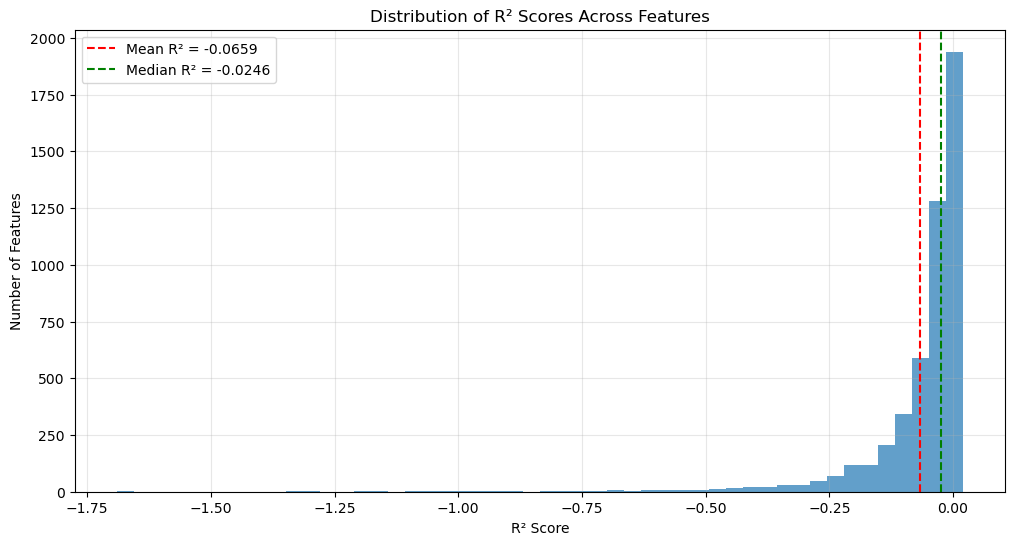

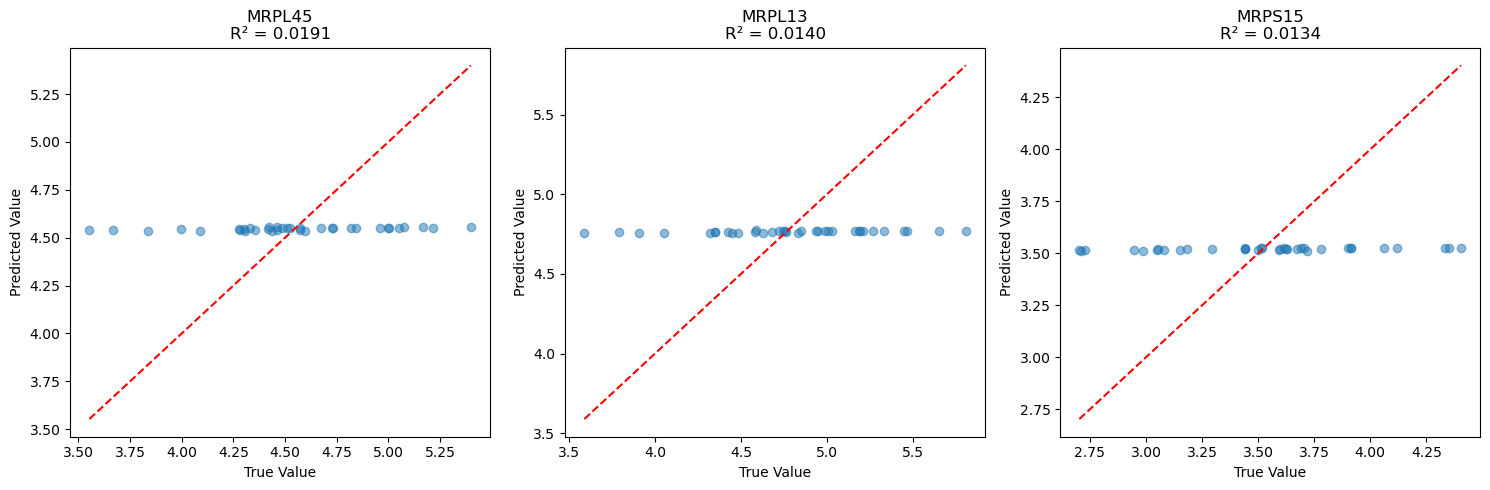

Feature performance metrics saved to /home/jantine/Projects/transformer_multiomics/results/feature_performance_metrics.csv


,Feature,R2,RMSE,MAE,Correlation,P_value
2446,MRPL45,0.019102,0.413490,0.320432,0.638788,3.632631e-05
2420,MRPL13,0.013959,0.500716,0.394715,0.755609,1.544061e-07
2463,MRPS15,0.013424,0.443770,0.351010,0.709182,1.852887e-06
186,ANK3,0.012831,0.393266,0.313622,0.483919,3.225774e-03
4157,SSR3,0.012662,0.681749,0.567311,0.753779,1.720269e-07
...,...,...,...,...,...,...
2602,NCL,-1.179102,0.624090,0.542963,-0.131458,4.516025e-01
1839,HNRNPU,-1.209140,0.590671,0.528095,-0.545944,6.928569e-04
1739,H4C1,-1.309113,0.893421,0.754688,-0.218552,2.071912e-01
1827,HNRNPC,-1.342779,0.509334,0.440839,-0.117214,5.024887e-01


In [15]:
# Define best_params
best_params = {
    "num_heads": 4,
    "num_layers": 6,
    "hidden_dim": 320,
    "dropout_rate": 0.1,
    "fusion_method": "gated",
    "activation_function": "relu",
}

# Analyse feature-level performance
print("\nAnalysing feature-level performance...")
model_path = MODEL_PATH / "best_model_transcriptomics.pth"
feature_performance = analyse_feature_level_performance(best_omics_set, best_params, datasets, model_path, device)

# Save feature performance metrics
feature_performance.to_csv(RESULT_PATH / "feature_performance_metrics.csv", index=False)
print(f"Feature performance metrics saved to {RESULT_PATH / 'feature_performance_metrics.csv'}")

feature_performance

# Best Predicting Protein Features <a id="results-feature-analysis"></a>

The results that the best predicting proteomic features actually have very low R^2 values, which indicates weak prediction performance and not a lot of variability is explained. The correlation values between the predicted and actual values >0.5 with significant p-values, so the model seems to capture some meaningful relationship between input omics data and protein expression, but not strongly. 


The disconnect between the correlation values and the very low R^2 values suggests that while the model is capturing some general trends in protein expression (hence the correlations), it's not accurately predicting the exact values (hence the poor R^2 values). This could be due to scaling issues in the predictions or systematic biases that the model hasn't learned to correct.


The RMSE values are consistently higher than MAE, suggesting some (larger) errors in the predictions. This because RMSE is more sensitive to outliers (quadratic penalty).